In [2]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
import numpy as np

In [35]:
df_charging_data = pd.read_csv('../data/charging_sessions.csv')
df_weather = pd.read_csv('../data/weather_burbank_airport.csv')

### General data overview 

#### EV charging data

In [5]:
df_charging_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        66450 non-null  int64  
 1   id                66450 non-null  object 
 2   connectionTime    66450 non-null  object 
 3   disconnectTime    66450 non-null  object 
 4   doneChargingTime  62362 non-null  object 
 5   kWhDelivered      66450 non-null  float64
 6   sessionID         66450 non-null  object 
 7   siteID            66450 non-null  int64  
 8   spaceID           66450 non-null  object 
 9   stationID         66450 non-null  object 
 10  timezone          66450 non-null  object 
 11  userID            49187 non-null  float64
 12  userInputs        49187 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 6.6+ MB


In [6]:
df_charging_data.isnull().sum()

Unnamed: 0              0
id                      0
connectionTime          0
disconnectTime          0
doneChargingTime     4088
kWhDelivered            0
sessionID               0
siteID                  0
spaceID                 0
stationID               0
timezone                0
userID              17263
userInputs          17263
dtype: int64

In [67]:
df_charging_data.head()

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,"[{'WhPerMile': 250, 'kWhRequested': 25.0, 'mil..."
1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,"[{'WhPerMile': 280, 'kWhRequested': 70.0, 'mil..."
2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil..."


#### Weather data

In [7]:
df_weather.head()

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature
0,Burbank,2018-01-01 08:53:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0
1,Burbank,2018-01-01 09:53:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0
2,Burbank,2018-01-01 10:53:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0
3,Burbank,2018-01-01 11:53:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0
4,Burbank,2018-01-01 12:53:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0


In [8]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29244 entries, 0 to 29243
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     29244 non-null  object 
 1   timestamp                29244 non-null  object 
 2   temperature              29219 non-null  float64
 3   cloud_cover              29224 non-null  float64
 4   cloud_cover_description  29224 non-null  object 
 5   pressure                 29236 non-null  float64
 6   windspeed                29158 non-null  float64
 7   precipitation            29244 non-null  float64
 8   felt_temperature         29218 non-null  float64
dtypes: float64(6), object(3)
memory usage: 2.0+ MB


### Data preparation

#### Drop duplicates

In [36]:
# Remove the "Unnamed: 0" column, as it represents the index and restarts from 1 at a certain point in the dataset
df_charging_data = df_charging_data.drop(columns=["Unnamed: 0"])

In [37]:
# Check for duplicates
duplicate_rows = df_charging_data.duplicated()
duplicate_count = duplicate_rows.sum()
duplicate_percentage = round(duplicate_count / df_charging_data.shape[0], 4) * 100
print(f"Absolute number of duplicate rows in the data: {duplicate_count}")
print(f"Percentage of duplicate rows in the data: {duplicate_percentage}%")

Absolute number of duplicate rows in the data: 1413
Percentage of duplicate rows in the data: 2.13%


In [38]:
# Drop duplicate rows
df_charging_data = df_charging_data.drop_duplicates()

#### Normalize nested data 

A nested JSON structure for the column "userInputs" can be seen. 
To make it easier to analyze the data, the nested structure should be broken down into multiple columns. 
Some of the rows might have multiple user inputs with different timestamps. 
-> These rows should be looked at more closely first.

In [39]:
# For col userInputs: Change string representation of Python list into a list to be able to count the length
df_charging_data['userInputs'] = df_charging_data['userInputs'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else None)

# Count the number of entries in each list
df_charging_data['inputCount'] = df_charging_data['userInputs'].apply(
    lambda x: len(x) if isinstance(x, list) else 0)

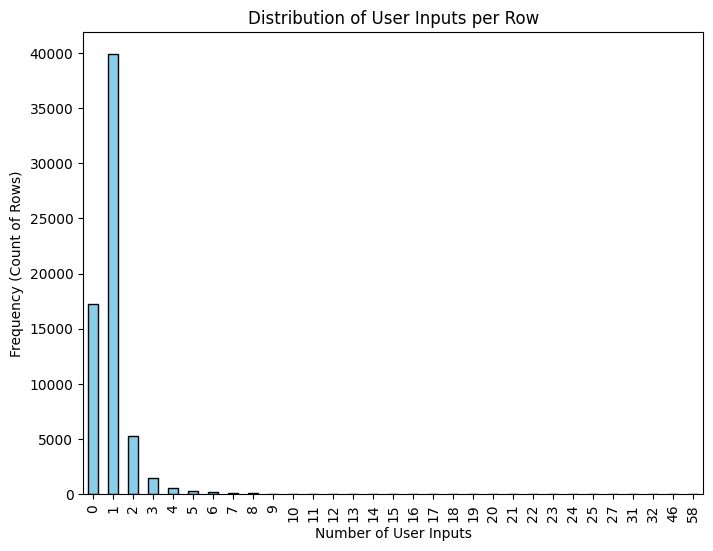

In [40]:
# Visualize the distribution for inputCount
distribution = df_charging_data['inputCount'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of User Inputs per Row")
plt.xlabel("Number of User Inputs")
plt.ylabel("Frequency (Count of Rows)")
plt.show()

In [43]:
# Count rows with more than one user input
count_multiple_inputs = (df_charging_data['inputCount'] > 1).sum()
per_multiple_inputs = round(count_multiple_inputs / df_charging_data.shape[0], 4) * 100
print(f"Absolute number of rows with multiple user inputs: {count_multiple_inputs}")
print(f"Percentage of rows with multiple user inputs: {per_multiple_inputs}%")

Absolute number of rows with multiple user inputs: 7905
Percentage of rows with multiple user inputs: 12.15%


-> More than 10% of the rows have multiple user inputs, so these should be looked at more closely instead of always taking the first dictionary of the list.

Compare the difference between the user inputs in a single session

In [ ]:
# Dataframe with all rows with more than one user input
df_multiple_inputs = df_charging_data[df_charging_data["inputCount"] > 1].copy()

def calculate_range(user_inputs, column, date_format="%a, %d %b %Y %H:%M:%S GMT"):
    """
    Calculate the range (max - min) of values for a specified column from a list of user inputs.

    Parameters:
        user_inputs (list of dict): A list of dictionaries where the values are the inputs provided by the user. 
        column (str): The key for which the range is to be calculated.
        date_format (str, optional): The date format string for the column if the column contains date strings.

    Returns:
        float: The range (max - min) of the values in the specified column.
    """
    values = [input_data[column] for input_data in user_inputs if column in input_data]
    if len(values) > 1:
        # If numeric, calculate range as max - min
        if isinstance(values[0], (int, float)):  
            return max(values) - min(values)
        # If string, attempt to convert to datetime and calculate the range
        elif isinstance(values[0], str):  
            values = pd.to_datetime(values, format=date_format, errors='coerce')  
            values = values.dropna()
            if len(values) > 1:
                return values.max() - values.min() 
            else:
                return pd.Timedelta(0)  
    return 0

# Columns to calculate the range for
columns_of_interest = ["WhPerMile", "kWhRequested", "milesRequested", "minutesAvailable", 
                       "modifiedAt", "requestedDeparture", "userID"]						
# Calculate range for each column safely
for column in columns_of_interest:
    df_multiple_inputs[f"{column}_range"] = df_multiple_inputs["userInputs"].apply(
        lambda x: calculate_range(x, column)
    )

# Select only the relevant columns to create final comparison DataFrame
cols = ["inputCount"] + ["userInputs"] + [f"{col}_range" for col in columns_of_interest]
user_inputs_range_df = df_multiple_inputs[cols]

In [140]:
user_inputs_range_df.head()

,inputCount,userInputs,WhPerMile_range,kWhRequested_range,milesRequested_range,minutesAvailable_range,modifiedAt_range,requestedDeparture_range,userID_range
3,2,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",0,0.0,0,0,0 days 00:00:16,0 days 00:00:00,0
17,3,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",0,0.0,0,139,0 days 02:41:46,0 days 02:19:00,0
19,2,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil...",0,0.0,0,287,0 days 00:00:09,0 days 04:47:00,0
20,2,"[{'WhPerMile': 350, 'kWhRequested': 42.0, 'mil...",0,14.0,40,44,0 days 01:00:19,0 days 00:44:00,0
31,3,"[{'WhPerMile': 600, 'kWhRequested': 78.0, 'mil...",0,12.0,20,2,0 days 00:02:43,0 days 00:02:00,0


In [99]:
def plot_top_n_distribution(df, input_count, column_for_distribution, top_n=10):
    """
    Filters the DataFrame based on input_count and plots the top n categories of the specified column.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame.
        input_count (int): The value of 'inputCount' to filter rows.
        column_for_distribution (str): The column to calculate and plot the distribution.
        top_n (int): Number of top categories to display.
        
    Returns:
        pd.Series: The top N distribution of the specified column, sorted by index.
    """
    import matplotlib.pyplot as plt

    # Filter the DataFrame
    filtered_df = df[df["inputCount"] == input_count]
    
    # Calculate the distribution and get the top N categories
    distribution = filtered_df[column_for_distribution].value_counts().nlargest(top_n).sort_index()
    
    # Plot the distribution
    plt.figure(figsize=(10, 6))
    distribution.plot(kind="bar")
    plt.title(f"Top {top_n} {column_for_distribution} for inputCount = {input_count}")
    plt.xlabel(column_for_distribution)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


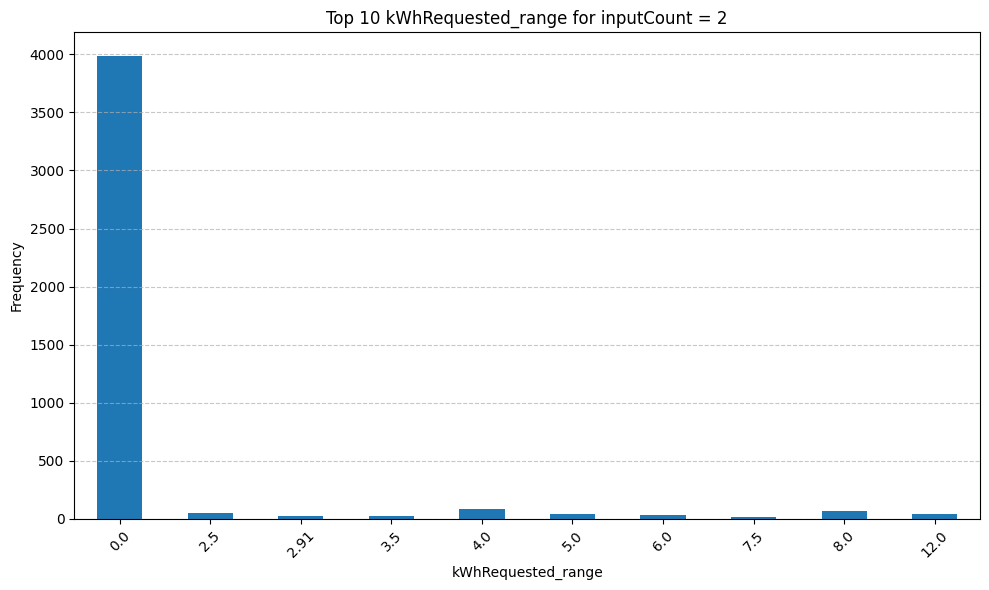

In [105]:
plot_top_n_distribution(user_inputs_range_df, 2, 'kWhRequested_range')

Executing the function with varying parameters leads to very similar results: 
 
Most of the time when multiple user inputs are stored, the inputs the user gave were the exact same, just with different timestamps for "modifiedAt" or a later departure time.  
Therefore it seems like a good solution to always take the last input of the driver and don't do complicated data aggregation or splitting rows up into individual rows with an additional input index as a column.  
In most cases it won't make a difference regarding the data and where it does it seems to be the most logical way to take the final input of the driver.

Unnest the "userInputs" column

In [147]:
# Process the column to get the last dictionary or an empty dictionary
processed_data = [
    lst[-1] if lst else {} 
    for lst in df_charging_data['userInputs']
]

# Convert the list of dictionaries into a new DataFrame
normalized_df = pd.json_normalize(processed_data)

normalized_df.head()

,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID
0,250.0,25.0,100.0,463.0,"Thu, 02 Jan 2020 13:09:39 GMT",True,"Thu, 02 Jan 2020 20:51:54 GMT",194.0
1,280.0,70.0,250.0,595.0,"Thu, 02 Jan 2020 13:37:11 GMT",True,"Thu, 02 Jan 2020 23:31:50 GMT",4275.0
2,400.0,8.0,20.0,60.0,"Thu, 02 Jan 2020 13:57:17 GMT",True,"Thu, 02 Jan 2020 14:56:35 GMT",344.0
3,400.0,8.0,20.0,65.0,"Thu, 02 Jan 2020 14:00:19 GMT",True,"Thu, 02 Jan 2020 15:04:58 GMT",1117.0
4,400.0,16.0,40.0,504.0,"Thu, 02 Jan 2020 14:00:13 GMT",True,"Thu, 02 Jan 2020 22:24:01 GMT",334.0


In [149]:
# Concatenate dataframes and drop userInputs column as the data is now stored in new columns

full_charging_df = pd.concat([df_charging_data.drop(columns=['userInputs']), 
                     normalized_df.drop(columns=['userID'])], axis=1)

In [150]:
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,inputCount,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture
0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,1,250.0,25.0,100.0,463.0,"Thu, 02 Jan 2020 13:09:39 GMT",True,"Thu, 02 Jan 2020 20:51:54 GMT"
1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,1,280.0,70.0,250.0,595.0,"Thu, 02 Jan 2020 13:37:11 GMT",True,"Thu, 02 Jan 2020 23:31:50 GMT"
2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,1,400.0,8.0,20.0,60.0,"Thu, 02 Jan 2020 13:57:17 GMT",True,"Thu, 02 Jan 2020 14:56:35 GMT"
3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,2,400.0,8.0,20.0,65.0,"Thu, 02 Jan 2020 14:00:19 GMT",True,"Thu, 02 Jan 2020 15:04:58 GMT"
4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,1,400.0,16.0,40.0,504.0,"Thu, 02 Jan 2020 14:00:13 GMT",True,"Thu, 02 Jan 2020 22:24:01 GMT"


#### Exporation and Preparation of the Time Data

First transform the the time zones to the correct time zone

In [13]:
time_columns = ["doneChargingTime", "connectionTime", "disconnectTime", "modifiedAt", "requestedDeparture"]

In [14]:
# Transform to pandas datetime datatype
full_charging_df[time_columns] = full_charging_df[time_columns].apply(
    lambda x: pd.to_datetime(x, utc=True))

In [15]:
# Transform the timestamps from UTC to the correct timezone
full_charging_df[time_columns] = full_charging_df[time_columns].apply(
    lambda col: col.dt.tz_convert("America/Los_Angeles"))

In [26]:
# Check new timestamps
full_charging_df["connectionTime"]
# -> -08:00 and -07:00 are the offsets from UTC time (-8 hours in winter, -7 in summer)

0       2020-01-02 05:08:54-08:00
1       2020-01-02 05:36:50-08:00
2       2020-01-02 05:56:35-08:00
3       2020-01-02 05:59:58-08:00
4       2020-01-02 06:00:01-08:00
                   ...           
66445   2019-07-31 11:08:04-07:00
66446   2019-07-31 11:40:41-07:00
66447   2019-07-31 12:04:40-07:00
66448   2019-07-31 12:19:47-07:00
66449   2019-07-31 12:21:47-07:00
Name: connectionTime, Length: 66450, dtype: datetime64[ns, America/Los_Angeles]

Create additional time related Columns for the time data

In [16]:
full_charging_df["connectionTimespan"] = full_charging_df["disconnectTime"] - full_charging_df["connectionTime"]
full_charging_df["doneDisconnectTimespan"] = full_charging_df["disconnectTime"] - full_charging_df["doneChargingTime"]
full_charging_df['connectionMonth'] = full_charging_df['connectionTime'].dt.month
full_charging_df['connectionWeekdayName'] = full_charging_df['connectionTime'].dt.day_name()
full_charging_df["connectionYear"] = full_charging_df["connectionTime"].dt.year
full_charging_df['isWeekend'] = full_charging_df['connectionTime'].dt.weekday >= 5

time_span_columns = ["connectionTimespan", "doneDisconnectTimespan"]

In [ ]:
def plot_histogram(ax, season_df: pd.DataFrame, year: str = None) -> None:
    """
    Helper function to plot a histogram for a single year's data on a given axis.
    """
    # Determine the minimum and maximum month numbers present in the DataFrame
    min_month = season_df['connectionMonth'].min()
    max_month = season_df['connectionMonth'].max()

    # Calculate the number of bins dynamically based on the range of months
    month_bins = max_month - min_month + 1

    # Plotting histogram
    counts, bins, patches = ax.hist(
        season_df['connectionMonth'], bins=month_bins, edgecolor='black',
        rwidth=0.8, range=(min_month - 0.5, max_month + 0.5)
    )

    # Configure the plot
    if year:
        ax.set_title(f"Year {year}")
    ax.set_xlabel('Month')
    ax.set_ylabel('Frequency')

    # Set x-ticks centered under each bar
    ax.set_xticks(np.arange(min_month, max_month + 1))
    ax.set_xticklabels(
        ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][min_month - 1:max_month]
    )

    ax.grid(axis='y', linestyle='--', alpha=0.7)

def plot_hist(dfs_by_year: dict = None, season_df: pd.DataFrame = None, title: str = "") -> None:
    """
    Plots a histogram for either multiple years (dfs_by_year) or a single year's data (season_df).
    """
    if dfs_by_year:
        num_years = len(dfs_by_year)
        fig, axes = plt.subplots(1, num_years, figsize=(15, 5), sharey=True)
        fig.suptitle(title)

        # Ensure axes is iterable for single subplot case
        if num_years == 1:
            axes = [axes]

        for i, (year, df) in enumerate(dfs_by_year.items()):
            plot_histogram(axes[i], df, year)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
        plt.show()
    elif season_df is not None:
        fig, ax = plt.subplots(figsize=(10, 6))
        plot_histogram(ax, season_df)
        plt.title(title)
        plt.tight_layout()
        plt.show()
    else:
        raise ValueError("Provide either 'dfs_by_year' or 'season_df' to plot.")

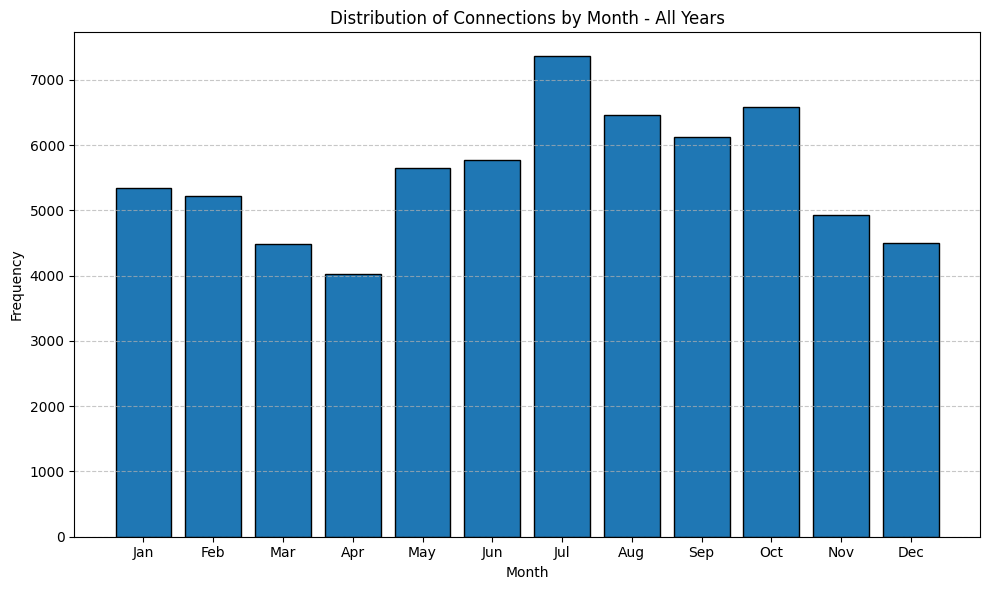

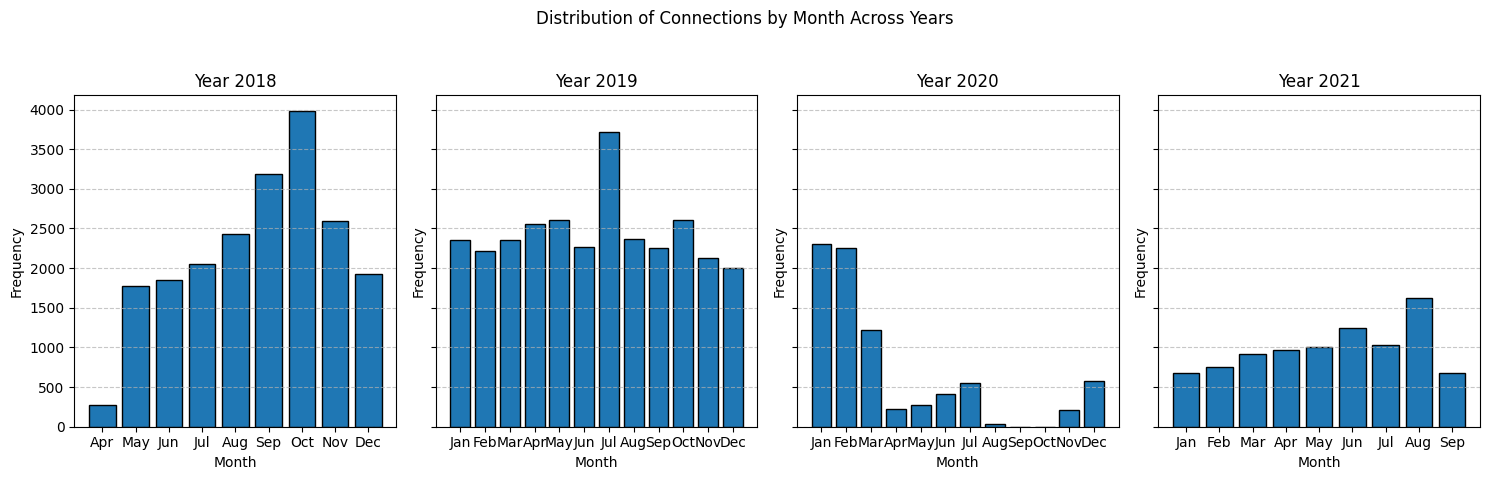

In [18]:
# Extract years from the DataFrame
years = [
    full_charging_df["connectionYear"].min() + year
    for year in range(
        full_charging_df["connectionYear"].max() - full_charging_df["connectionYear"].min() + 1
    )
]

# Create a dictionary of DataFrames by year
dfs_by_year = {
    year: full_charging_df[full_charging_df["connectionYear"] == year]
    for year in years
}

# Plot for all years combined
plot_hist(season_df=full_charging_df, title='Distribution of Connections by Month - All Years')

# Plot for each year individually
plot_hist(dfs_by_year=dfs_by_year, title="Distribution of Connections by Month Across Years")

Here there are a few things to see.
1. we start collecting records from April 2018 to September 2021
2. Somehow in March/April 2020 the data shows a steep fall while it never fully recovers to the old amounts
3. in September and October there don't seem to be any records

**April 2020 fall of records** 
The Fall in April 2020 can most likely be explained with Corona.
As suggested in this website: https://myburbank.com/latest-official-coronavirus-news-concerning-burbank/ (search for "March 22 – Burbank Gives Updated L. A, County Revised Order for Stronger “Safer at Home” Order") it may be due to the lockdown restrictions.

**September/October 2020 no records found**
The data for September and october looks a little bit different and needs further investigation

In [19]:
months = [8, 9, 10, 11]
for month in months:
    monthly_data_2020 = dfs_by_year.get(2020)[dfs_by_year.get(2020)["connectionMonth"] == month]
    print(month ,set(monthly_data_2020['connectionTime'].dt.day))

8 {1, 2, 3}
9 set()
10 set()
11 {18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30}


This data implies that from the 03.08.2020 to the 17.11.2020 we collected no records may due to broken sensors or something similar.

In [20]:
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,...,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,connectionTimespan,doneDisconnectTimespan,connectionMonth,connectionWeekdayName,connectionYear,isWeekend
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,...,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00,0 days 06:02:21,0 days 01:39:40,1,Thursday,2020,False
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,...,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00,0 days 09:01:31,0 days 02:20:16,1,Thursday,2020,False
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,...,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00,0 days 10:42:47,0 days 08:04:16,1,Thursday,2020,False
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,...,65.0,2020-01-02 06:00:03-08:00,True,2020-01-02 07:04:58-08:00,0 days 02:38:41,0 days 01:19:54,1,Thursday,2020,False
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,...,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00,0 days 08:08:39,0 days 03:51:10,1,Thursday,2020,False


Now we can explore the time data
Look for negative or NaN values

In [21]:
time_columns

['doneChargingTime',
 'connectionTime',
 'disconnectTime',
 'modifiedAt',
 'requestedDeparture']

In [22]:
for time_column in time_columns:
    print(f"{time_column}: {full_charging_df[time_column].isnull().sum()}")

doneChargingTime: 4088
connectionTime: 0
disconnectTime: 0
modifiedAt: 17263
requestedDeparture: 17263


In [23]:
for time_span_column in time_span_columns:
    column_type = full_charging_df[time_span_column].dtype
    negative_timedelta = full_charging_df[time_span_column] < pd.Timedelta(0)
    negative_count = negative_timedelta.sum()
    print(f"{time_span_column}: {negative_count} rows with negative timespans")

connectionTimespan: 0 rows with negative timespans
doneDisconnectTimespan: 4692 rows with negative timespans


In [24]:
# These Negatives should not exist
part = full_charging_df[full_charging_df["doneDisconnectTimespan"] < pd.Timedelta(0)]
len(part)

4692

In [25]:
len(full_charging_df["doneDisconnectTimespan"]) - len(part)

61758

In [27]:
# Calculate the timespan in which the car was connected to the station
full_charging_df["connectionTimespan"].describe()

count                        66450
mean     0 days 06:17:34.578209179
std      0 days 04:51:41.391314114
min                0 days 00:02:04
25%         0 days 02:51:57.750000
50%                0 days 06:11:44
75%         0 days 09:13:31.500000
max               10 days 05:16:09
Name: connectionTimespan, dtype: object

In [28]:
# Final dataframe (currently)
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,...,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,connectionTimespan,doneDisconnectTimespan,connectionMonth,connectionWeekdayName,connectionYear,isWeekend
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,...,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00,0 days 06:02:21,0 days 01:39:40,1,Thursday,2020,False
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,...,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00,0 days 09:01:31,0 days 02:20:16,1,Thursday,2020,False
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,...,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00,0 days 10:42:47,0 days 08:04:16,1,Thursday,2020,False
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,...,65.0,2020-01-02 06:00:03-08:00,True,2020-01-02 07:04:58-08:00,0 days 02:38:41,0 days 01:19:54,1,Thursday,2020,False
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,...,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00,0 days 08:08:39,0 days 03:51:10,1,Thursday,2020,False


We have now completed the data exploration and the preparation of the time-dependent data. We now need to decide how to deal with the invalid values we found during data exploration. If there is something we haven't seen yet, it will most likely come up when working on the other tasks.

In [29]:
profile = ProfileReport(full_charging_df, title="Profiling Report")
# profile.to_file("full_charging_data_report.html")

In [30]:
# Example Usage of the ProfileReport
profile.get_duplicates()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/Noah/Uni Köln Git/Team-Assignment/venv/lib/python3.11/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with timedelta64[ns], please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/Users/Noah/Uni Köln Git/Team-Assignment/venv/lib/python3.11/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 0. 0. ... 0. 0. 0.]' has dtype incompatible with timedelta64[ns], please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/Users/Noah/Uni Köln Git/Team-Assignment/venv/lib/python3.11/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Set

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,...,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,connectionMonth,connectionWeekdayName,connectionYear,isWeekend,# duplicates
0,5d2fbdd3f9af8b4d0dd0d54f,2019-07-01 17:32:46-07:00,2019-07-01 19:34:56-07:00,2019-07-01 18:46:09-07:00,2.463,1_1_193_827_2019-07-02 00:32:45.820079,1,AG-1F02,1-1-193-827,America/Los_Angeles,...,20.0,90.0,2019-07-01 17:32:53-07:00,True,2019-07-01 19:02:46-07:00,7,Monday,2019,False,2
1,5d310f54f9af8b52adda3e20,2019-07-02 05:15:28-07:00,2019-07-02 09:01:01-07:00,2019-07-02 09:01:38-07:00,12.891,1_1_194_818_2019-07-02 12:15:28.503952,1,AG-1F14,1-1-194-818,America/Los_Angeles,...,70.0,332.0,2019-07-02 05:18:12-07:00,True,2019-07-02 10:47:28-07:00,7,Tuesday,2019,False,2
2,5d310f54f9af8b52adda3e21,2019-07-02 05:42:49-07:00,2019-07-02 12:34:19-07:00,2019-07-02 09:21:21-07:00,13.734,1_1_178_828_2019-07-02 12:42:48.733464,1,AG-1F10,1-1-178-828,America/Los_Angeles,...,50.0,186.0,2019-07-02 05:43:19-07:00,True,2019-07-02 08:48:49-07:00,7,Tuesday,2019,False,2
3,5d310f54f9af8b52adda3e22,2019-07-02 05:44:46-07:00,2019-07-02 15:33:29-07:00,2019-07-02 09:28:09-07:00,10.619,1_1_178_823_2019-07-02 12:44:45.734064,1,AG-1F08,1-1-178-823,America/Los_Angeles,...,40.0,581.0,2019-07-02 05:45:09-07:00,True,2019-07-02 15:25:46-07:00,7,Tuesday,2019,False,2
4,5d310f54f9af8b52adda3e23,2019-07-02 05:52:53-07:00,2019-07-02 12:21:25-07:00,2019-07-02 10:55:13-07:00,19.079,1_1_179_799_2019-07-02 12:52:52.691064,1,AG-3F25,1-1-179-799,America/Los_Angeles,...,260.0,534.0,2019-07-02 05:53:40-07:00,True,2019-07-02 14:46:53-07:00,7,Tuesday,2019,False,2
5,5d310f54f9af8b52adda3e24,2019-07-02 06:02:13-07:00,2019-07-02 12:04:02-07:00,2019-07-02 07:14:25-07:00,2.414,1_1_193_827_2019-07-02 13:02:12.544018,1,AG-1F02,1-1-193-827,America/Los_Angeles,...,20.0,90.0,2019-07-02 06:02:13-07:00,True,2019-07-02 07:32:13-07:00,7,Tuesday,2019,False,2
6,5d310f54f9af8b52adda3e25,2019-07-02 06:05:00-07:00,2019-07-02 15:13:28-07:00,2019-07-02 10:33:35-07:00,12.130,1_1_193_819_2019-07-02 13:05:00.715639,1,AG-1F06,1-1-193-819,America/Los_Angeles,...,50.0,455.0,2019-07-02 06:05:09-07:00,True,2019-07-02 13:40:00-07:00,7,Tuesday,2019,False,2
7,5d310f54f9af8b52adda3e26,2019-07-02 06:14:59-07:00,2019-07-02 16:07:57-07:00,2019-07-02 09:31:16-07:00,7.316,1_1_193_820_2019-07-02 13:14:59.483416,1,AG-1F04,1-1-193-820,America/Los_Angeles,...,20.0,646.0,2019-07-02 06:15:13-07:00,True,2019-07-02 17:00:59-07:00,7,Tuesday,2019,False,2
8,5d310f54f9af8b52adda3e27,2019-07-02 06:18:28-07:00,2019-07-02 16:16:24-07:00,2019-07-02 15:45:11-07:00,18.368,1_1_179_788_2019-07-02 13:18:27.824619,1,AG-3F22,1-1-179-788,America/Los_Angeles,...,60.0,541.0,2019-07-02 06:18:44-07:00,True,2019-07-02 15:19:28-07:00,7,Tuesday,2019,False,2
9,5d310f54f9af8b52adda3e28,2019-07-02 06:25:01-07:00,2019-07-02 15:39:18-07:00,2019-07-02 09:29:23-07:00,13.924,1_1_178_817_2019-07-02 13:25:01.464654,1,AG-1F09,1-1-178-817,America/Los_Angeles,...,60.0,418.0,2019-07-02 06:25:07-07:00,True,2019-07-02 13:23:01-07:00,7,Tuesday,2019,False,2


In [31]:
# This code is generated by Copilot to save time codeing time. Copilot should generate the framework for an linear regression and i tried differnt x and y values to get a better prediction.
# The code evolved in an iterative try and error approach also using copilot. 
# Calculate the duration of the charging session, not the time until disconnection
full_charging_df['chargingDuration'] = (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds()

# Tries to fill null values in doneChargingTime with prediction based on connectionTimespan and kWhDelivered. Is Probably a bit too complex for the task and quality of predictions could still be better

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

def preprocess_data(df):
    df['connectionTime'] = pd.to_datetime(df['connectionTime'])
    df['doneChargingTime'] = pd.to_datetime(df['doneChargingTime'])
    
    # Assuming: connectionTimespan is a timespan in usable format (e.g. timedelta)
    df['connectionTimespan'] = pd.to_timedelta(df['connectionTimespan'])
    df['connectionTimespan'] = df['connectionTimespan'].dt.total_seconds()
    return df

# Assuming full_charging_df is already loaded
preprocess_df = preprocess_data(full_charging_df)

# Separate rows with and without null values in 'doneChargingTime'
df_with_doneChargingTime = preprocess_df.dropna(subset=['doneChargingTime'])
df_without_doneChargingTime = full_charging_df[full_charging_df['doneChargingTime'].isna()]

# Prepare data for training
X = df_with_doneChargingTime[['connectionTimespan', 'kWhDelivered', 'stationID', 'userID']]
y = df_with_doneChargingTime['chargingDuration']

# One-Hot-Encoding für stationID und userID
column_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['connectionTimespan', 'kWhDelivered']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['stationID', 'userID'])
    ],
    remainder='passthrough'
)

# Pipeline für die Transformation und das lineare Modell
pipeline = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('regressor', LinearRegression())
])

# Aufteilen der Daten in Trainings- und Testdatensatz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Trainieren des linearen Modells
pipeline.fit(X_train, y_train)

# Vorhersagen und Evaluierung des linearen Modells
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

differences = np.abs(y_test - y_pred)
differences_in_hours = differences / 3600
accurate_predictions = np.sum(differences_in_hours <= 1)
total_predictions = len(y_test)
accuracy_percentage = (accurate_predictions / total_predictions) * 100
print(f'Prozentuale Genauigkeit: {accuracy_percentage:.2f}%')

# Vorhersagen für die Zeilen ohne doneChargingTime
X_missing = df_without_doneChargingTime[['connectionTimespan', 'kWhDelivered', 'stationID', 'userID']]
X_missing_transformed = column_transformer.transform(X_missing)
# Überprüfen der Anzahl der Merkmale nach der Transformation
print(f'Anzahl der Merkmale nach der Transformation: {X_missing_transformed.shape[1]}')

y_missing_pred = pipeline.named_steps['regressor'].predict(X_missing_transformed)

# Aktualisieren der null-Werte in doneChargingTime mit den vorhergesagten Werten
df_without_doneChargingTime.loc[:, 'chargingDuration'] = y_missing_pred

# Sicherstellen, dass connectionTimespan in float umgewandelt wird, bevor es in Timedelta konvertiert wird
df_without_doneChargingTime.loc[:, 'connectionTimespan'] = df_without_doneChargingTime['connectionTimespan'].astype(float)
df_without_doneChargingTime.loc[:, 'connectionTimespan'] = pd.to_timedelta(df_without_doneChargingTime['connectionTimespan'], unit='s')

# Berechnen der doneChargingTime
df_without_doneChargingTime.loc[:, 'doneChargingTime'] = df_without_doneChargingTime['connectionTime'] + pd.to_timedelta(df_without_doneChargingTime['chargingDuration'], unit='s')

# Zusammenführen der DataFrames
full_charging_df = pd.concat([df_with_doneChargingTime, df_without_doneChargingTime])

print(full_charging_df.head())


Mean Squared Error: 56531727.697049275
Prozentuale Genauigkeit: 63.73%
Anzahl der Merkmale nach der Transformation: 954
                         id            connectionTime  \
0  5e23b149f9af8b5fe4b973cf 2020-01-02 05:08:54-08:00   
1  5e23b149f9af8b5fe4b973d0 2020-01-02 05:36:50-08:00   
2  5e23b149f9af8b5fe4b973d1 2020-01-02 05:56:35-08:00   
3  5e23b149f9af8b5fe4b973d2 2020-01-02 05:59:58-08:00   
4  5e23b149f9af8b5fe4b973d3 2020-01-02 06:00:01-08:00   

             disconnectTime          doneChargingTime  kWhDelivered  \
0 2020-01-02 11:11:15-08:00 2020-01-02 09:31:35-08:00        25.016   
1 2020-01-02 14:38:21-08:00 2020-01-02 12:18:05-08:00        33.097   
2 2020-01-02 16:39:22-08:00 2020-01-02 08:35:06-08:00         6.521   
3 2020-01-02 08:38:39-08:00 2020-01-02 07:18:45-08:00         2.355   
4 2020-01-02 14:08:40-08:00 2020-01-02 10:17:30-08:00        13.375   

                                sessionID  siteID  spaceID    stationID  \
0  1_1_179_810_2020-01-02 13:08:53.

/var/folders/p_/nglzb5w16sq5fjgzxhpjqm580000gp/T/ipykernel_2087/1476380728.py:81: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<TimedeltaArray>
['0 days 11:06:36', '0 days 04:35:10', '0 days 08:03:19', '0 days 02:31:47',
 '0 days 08:37:02', '0 days 06:00:42', '0 days 03:07:01', '0 days 00:31:38',
 '0 days 08:58:55', '0 days 00:47:56',
 ...
 '0 days 02:29:43', '0 days 09:03:06', '0 days 10:23:02', '0 days 09:37:47',
 '0 days 05:00:33', '0 days 01:51:04', '0 days 04:19:27', '0 days 00:54:26',
 '0 days 00:54:16', '0 days 00:24:22']
Length: 4088, dtype: timedelta64[ns]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_without_doneChargingTime.loc[:, 'connectionTimespan'] = pd.to_timedelta(df_without_doneChargingTime['connectionTimespan'], unit='s')
